In [2]:
# make sure to choose the python_course environment

# import libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

#load dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [3]:
df_US = df[df['job_country'] == 'United States'].copy()

In [4]:
df_US['job_posted_month'] = df_US['job_posted_date'].dt.strftime('%B')


In [5]:
df_US_pivot = df_US.pivot_table(
    index = 'job_posted_month',
    columns = 'job_title_short',
    aggfunc = 'size'

)

In [6]:
# now we need the job month number (Jan is 1, etc)

df_US_pivot.reset_index(inplace=True)
df_US_pivot['month_number'] = pd.to_datetime(df_US_pivot['job_posted_month'], format='%B').dt.month # this extracts the month

In [7]:
df_US_pivot['month_number']

0      4
1      8
2     12
3      2
4      1
5      7
6      6
7      3
8      5
9     11
10    10
11     9
Name: month_number, dtype: int32

In [8]:
df_US_pivot.sort_values('month_number')

job_title_short,job_posted_month,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer,month_number
4,January,527,36,8494,2655,6915,60,1544,773,1552,114,1
3,February,447,24,6124,3060,4956,56,1258,878,1127,90,2
7,March,438,19,6218,3183,4779,59,1114,829,1150,115,3
0,April,565,40,6049,2801,4867,51,1025,781,991,112,4
8,May,279,20,4993,2976,4377,49,839,746,914,90,5
6,June,446,32,5683,2893,4645,48,1009,812,1033,93,6
5,July,581,39,5201,2570,4876,65,883,747,1095,153,7
1,August,903,39,6634,3269,6318,68,1186,903,1515,194,8
11,September,897,50,4639,3224,4568,113,805,775,1014,228,9
10,October,932,48,5271,3015,4882,101,871,672,987,219,10


In [9]:
df_US_pivot.set_index('job_posted_month', inplace=True)
df_US_pivot.drop(columns = 'month_number', inplace=True)

In [10]:
df_US_pivot.set_index('job_title_short', inplace=True)

KeyError: "None of ['job_title_short'] are in the columns"

In [11]:
df_US_pivot.index

Index(['April', 'August', 'December', 'February', 'January', 'July', 'June',
       'March', 'May', 'November', 'October', 'September'],
      dtype='str', name='job_posted_month')

In [14]:
df_US_pivot.head()

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
April,565,40,6049,2801,4867,51,1025,781,991,112
August,903,39,6634,3269,6318,68,1186,903,1515,194
December,648,40,3979,2641,3472,119,601,689,752,212
February,447,24,6124,3060,4956,56,1258,878,1127,90
January,527,36,8494,2655,6915,60,1544,773,1552,114


In [15]:
df_US_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
April,565,40,6049,2801,4867,51,1025,781,991,112
August,903,39,6634,3269,6318,68,1186,903,1515,194
December,648,40,3979,2641,3472,119,601,689,752,212
February,447,24,6124,3060,4956,56,1258,878,1127,90
January,527,36,8494,2655,6915,60,1544,773,1552,114
July,581,39,5201,2570,4876,65,883,747,1095,153
June,446,32,5683,2893,4645,48,1009,812,1033,93
March,438,19,6218,3183,4779,59,1114,829,1150,115
May,279,20,4993,2976,4377,49,839,746,914,90


In [19]:
df_US_software_pivot = pd.read_csv("https://lukeb.co/software_csv", index_col="job_posted_month") 
# we can shift the job posted month to be the index in the method

In [21]:
# merge the dataframes, like SQL but different syntax

df_US_merged = df_US_pivot.merge(df_US_software_pivot, on="job_posted_month")
# the "how" portion in a merge is like specifying the JOIN in SQL (How="Left", "Right", "Inner", "Outer". Default set as INNER)

In [ ]:
# the goal here is to plot the top 5 jobs based on count of jobs of the year. 


top_5 = (
    df_US_merged
    .sum() 
    .sort_values(ascending=False)
    .head()
    .index
    .tolist() # formats it into a list
    ) # when writing a long method, it's easier to read if you put it all in parenthesis and format it
# indent at each period, easier to leave comments at each line


top_5 # its a good idea to print as you go along



['Front-End Developer',
 'Back-End Developer',
 'Full-Stack Developer',
 'Data Analyst',
 'Data Scientist']

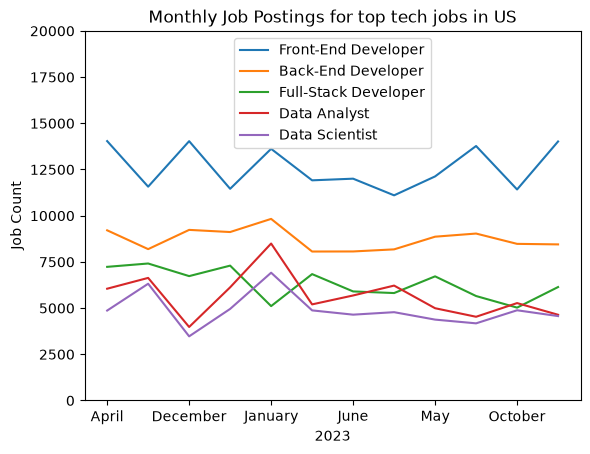

In [ ]:
df_US_merged[top_5].plot(kind='line')
plt.title("Monthly Job Postings for top tech jobs in US")
plt.xlabel("2023")
plt.ylabel('Job Count')
plt.ylim(0, 20000) # helps lower the intervals on y axis
plt.legend()
plt.show()